# Проект для «Викишоп» с BERT

## Описание проекта

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в
вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию.

**Цель проекта —** Построить модель классификации комментариев на позитивные и негативны со значением метрики качества F1 не меньше 0.75.

## Установка и импорт библиотек, определение констант

In [1]:
# Стандартные библиотеки Python
import gc
import os
import re

# Сторонние библиотеки общего назначения
import nltk
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Библиотеки для обработки естественного языка
from nltk.corpus import stopwords
import spacy

# Библиотеки для научных вычислений и статистики
from scipy.stats import loguniform

# Модули scikit-learn для обработки текста и машинного обучения
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Библиотеки для трансформеров и глубокого обучения
import transformers

# Библиотека для градиентного бустинга
from xgboost import XGBClassifier

# Библиотека для облаков слов
from wordcloud import WordCloud

# Настройка стиля графиков
sns.set(style="whitegrid")

In [2]:
TEST_SIZE = 0.25
RANDOM_STATE = 42

BATCH_SIZE = 256  # уменьшить, если не хватает RAM
MAX_LEN = 128    # достаточно для большинства комментариев

## Загрузка данных

In [3]:
# Загрузим файл с комментариями
try:
    # Пробуем основной путь
    df_init = pd.read_csv('/datasets/toxic_comments.csv')

except FileNotFoundError:
    print("⚠️ Файл не найден в /datasets/, пробуем из текущей директории...")
    try:
        df_init = pd.read_csv('toxic_comments.csv')
        print("✅ Файл 'toxic_comments.csv' найден в текущей директории.")
    except FileNotFoundError:
        print("❌ Ошибка: Файл 'toxic_comments.csv' не найден ни в /datasets/, ни в текущей директории.")

except Exception as e:
    print(f"❌ Критическая ошибка при загрузке данных: {str(e)}")

⚠️ Файл не найден в /datasets/, пробуем из текущей директории...
✅ Файл 'toxic_comments.csv' найден в текущей директории.


In [4]:
df_copy = df_init.drop('Unnamed: 0', axis=1)
df_copy.head(3)

,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0


**Промежуточный вывод**

Все данные из описания присутствуют, загрузка прошла успешно. Данные готовы к анализу.

## Анализ данных

In [5]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ MB


Признаки имеют требуемый тип данных и не содержат пропуски.

In [6]:
# количество дубликатов
df_copy.duplicated().sum()

0

Явные дубликаты отсутствуют

In [7]:
# Проверка на аномально длинные тексты
df_copy['text_len'] = df_copy['text'].fillna("").str.len()
print(df_copy['text_len'].describe())
print("Макс. длина:", df_copy['text_len'].max())

count    159292.000000
mean        393.691303
std         590.111825
min           5.000000
25%          95.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_len, dtype: float64
Макс. длина: 5000


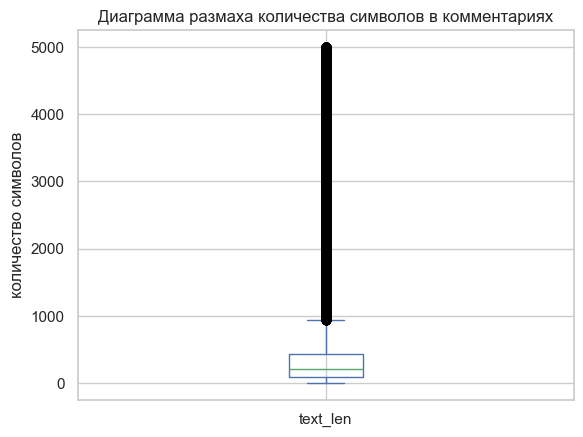

In [8]:
# Построим диаграмму размаха для количества символов в комментариях
df_copy['text_len'].plot(
    kind='box',
    title='Диаграмма размаха количества символов в комментариях'
)
plt.ylabel('количество символов')
plt.show()

In [9]:
# Рассмотрим некоторые длинные комментарии по символьно
long_texts_neg = df_copy[(df_copy['text'].str.len() > 2000) & (df_copy['toxic'] == 1)]['text']

for t in long_texts_neg.head(5):
    print(repr(t[:200]))  # первые 200 символов
    print("...")

'"  WILL MY MOTHERFUCKING SAFETY BE GUARANTEED???? I FUCKING HOPE SO!!! I\'M BRINGING MY OWN FUCKIN\' WEAPONS!! PAY ME WHEN I GET BACK MOTHERFUCKERS!!!  OH YEAH I\'VE GOT A JOKE...A FAMILY (HUSBAND, WIFE,'
...
'YOUR ARE FUCKING GAY WAD!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!'
...
'YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJER FUCKER COCKSUCKER! YOU ARE A MOTHJ'
...
'User:NHRHS2010 is a homo like mitt romney is. \nUser:NHRHS2010 is a homo like mitt romney is.\n User:Enigmaman is a homo like mitt romney is. \nUser:Enigmaman is a homo like mitt romney is.\n User:NHRHS20'
...
'FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUCK YOU U USELESS BOT FUC

In [10]:
# Рассмотрим некоторые длинные комментарии по символьно
long_texts_pos = df_copy[(df_copy['text'].str.len() > 2000) & (df_copy['toxic'] == 0)]['text']

for t in long_texts_pos.head(5):
    print(repr(t[:200]))  # первые 200 символов
    print("...")

'"\nFair use rationale for Image:Wonju.jpg\n\nThanks for uploading Image:Wonju.jpg. I notice the image page specifies that the image is being used under fair use but there is no explanation or rationale a'
...
'"\n\nBI, you said you wanted to talk\n\nAt the bottom of the lead section you have written:\n\n""Its promoter speculated in 1994 that the skyhook concept could be cost competitive with what is realistically'
...
'"\n\nIs it scientific to attribute an event A, to cause B, where cause B was deliberate designed, with some sort of intelligent intent? Don\'t answer the questions beyond that\nWell, the problem with not '
...
'Ahh, Hello Witzeman \n\n203.92.84.161  \nSymbols: ~ | ¡ ¿ † ‡ ↔ ↑ ↓ • ¶   # ½ ⅓ ⅔ ¼ ¾ ⅛ ⅜ ⅝ ⅞ ∞   ‘ “ ’ ” «»   ¤ ₳ ฿ ₵ ¢ ₡ ₢ $ ₫ ₯ € ₠ ₣ ƒ ₴ ₭ ₤ ℳ ₥ ₦ № ₧ ₰ £ ៛ ₨ ₪ ৳ ₮ ₩ ¥   ♠ ♣ ♥ ♦   m² m³ \nCharacters:'
...
'"== Attributing and classifying of personalities == \nInvitation. Your input to Culture of Lithuania is welcomed. \nSome problems of defining personalitie

Наблюдаем лишние символы, чтобы улучшить результаты модели классификации, очистим данные с помощью регулярных выражений.

In [11]:
# Функция очистки
def clean_text(text):
    # Проверка на пустые значения
    if not isinstance(text, str):
        return ""

    #1. Приведение к нижнему регистру
    text = text.lower()

    # 2. Удаление HTML-тегов
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Удаление URL и email
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # 4. Удаление цифр
    text = re.sub(r'\d+', ' ', text)

    # 5. Оставить только буквы английского алфавита и апострофы (для don't, isn't и т.д.)
    text = re.sub(r"[^a-z']+", ' ', text)

    # 6. Удалить одиночные апострофы в начале/конце и "висячие" апострофы
    text = re.sub(r"'\s+", ' ', text)
    text = re.sub(r"\s+'", ' ', text)
    text = re.sub(r"^'+|'+$", '', text)

    # 7. Нормализация пробелов
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
# Очистим данные
df_copy['text'] = df_copy['text'].fillna('')
df_copy['text_clean'] = [clean_text(text) for text in df_copy['text']]

Далее проведем лемматизацию с помощью spacy.

In [13]:
# Загрузка английской модели (без компонентов, которые не нужны для лемматизации)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])

# Определение функции для лемматизации
def lemmatize_text(text: str) -> str:
    """
    Лемматизирует текст с помощью spaCy.
    Возвращает строку из лемм, разделённых пробелами.
    """
    if not text.strip(): # Проверка на пустой текст
        return ""
    doc = nlp(text) # spaCy обрабатывает текст и создает объект doc (содержит: Токены, Лингвистические атрибуты)
    # Сохраняем только леммы слов (игнорируем пробелы и пустые токены)
    lemmas = [token.lemma_.lower() for token in doc if not token.is_space and token.is_alpha] # Игнорирует пробелы, оставляет только слова
    return " ".join(lemmas) # Возврат результата

In [14]:
%%time
# Лемматизация
df_copy['text_lemmatized'] = [lemmatize_text(text) for text in tqdm(df_copy['text_clean'], desc="Лемматизация")]

Лемматизация:   0%|          | 0/159292 [00:00<?, ?it/s]

CPU times: total: 26min 14s
Wall time: 28min 6s


In [32]:
df_text_1 = df_copy.copy()

In [33]:
def analyze_class_balance(df, target_column, figsize=(15, 10)):
    """
    Проводит комплексный анализ сбалансированности классов в целевом признаке.

    Функция вычисляет базовую статистику распределения классов, оценивает
    уровень дисбаланса и визуализирует распределение с помощью круговой диаграммы.

    Parameters
    ----------
    df : pandas.DataFrame
        Датафрейм с данными для анализа.
    target_column : str
        Название столбца с целевой переменной.
    figsize : tuple, optional
        Размер фигуры для графиков, по умолчанию (15, 10).

    Returns
    -------
    tuple
        Кортеж с тремя элементами:
        - class_counts : pandas.Series
            Количество наблюдений для каждого класса.
        - class_percentages : pandas.Series
            Процентное соотношение каждого класса.
        - imbalance_ratio : float
            Соотношение дисбаланса (наибольший класс / наименьший класс).

    Examples
    --------
    >>> class_counts, class_percentages, imbalance_ratio = analyze_class_balance(
    ...     df_copy, 'toxic'
    ... )
    >>> print(f"Соотношение дисбаланса: {imbalance_ratio:.2f}:1")
    """
    print("=" * 60)
    print("АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ")
    print("=" * 60)

    # Базовая статистика
    class_counts = df[target_column].value_counts()
    class_percentages = df[target_column].value_counts(normalize=True) * 100

    print(f"Всего наблюдений: {len(df):,}")
    print(f"Количество классов: {len(class_counts)}")
    print("\n" + "-" * 40)
    print("РАСПРЕДЕЛЕНИЕ КЛАССОВ:")
    print("-" * 40)

    for class_name, count, percentage in zip(class_counts.index,
                                           class_counts.values,
                                           class_percentages.values):
        print(f"Класс '{class_name}': {count:,} наблюдений ({percentage:.2f}%)")

    # Расчет метрик дисбаланса
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count

    print(f"\nМЕТРИКИ ДИСБАЛАНСА:")
    print(f"Соотношение дисбаланса: {imbalance_ratio:.2f}:1")
    print(f"Наибольший класс в {imbalance_ratio:.1f} раз больше наименьшего")

    # Оценка уровня дисбаланса
    if imbalance_ratio < 2:
        imbalance_level = "СЛАБЫЙ"
    elif imbalance_ratio < 10:
        imbalance_level = "УМЕРЕННЫЙ"
    else:
        imbalance_level = "СИЛЬНЫЙ"

    print(f"Уровень дисбаланса: {imbalance_level}")

    # Круговая диаграмма
    plt.figure(figsize=(8, 6))

    # Создаем круговую диаграмму
    plt.pie(
        class_counts.values,
        labels=class_counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66c2a5', '#fc8d62'],
        textprops={'fontsize': 10}
    )

    plt.title(
        f'Распределение классов: {target_column}',
        fontsize=14,
        fontweight='bold'
    )
    plt.show()

    return class_counts, class_percentages, imbalance_ratio

АНАЛИЗ СБАЛАНСИРОВАННОСТИ КЛАССОВ
Всего наблюдений: 159,292
Количество классов: 2

----------------------------------------
РАСПРЕДЕЛЕНИЕ КЛАССОВ:
----------------------------------------
Класс '0': 143,106 наблюдений (89.84%)
Класс '1': 16,186 наблюдений (10.16%)

МЕТРИКИ ДИСБАЛАНСА:
Соотношение дисбаланса: 8.84:1
Наибольший класс в 8.8 раз больше наименьшего
Уровень дисбаланса: УМЕРЕННЫЙ


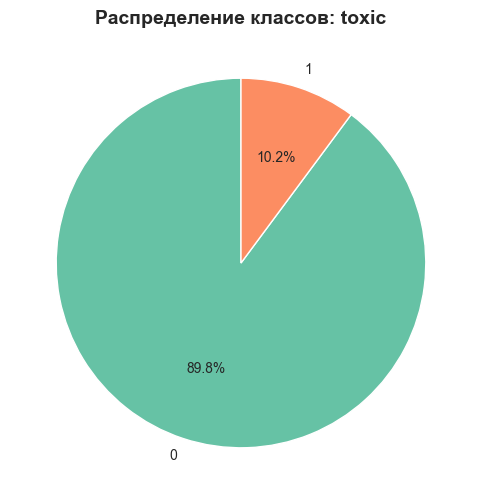

In [34]:
# Применяем анализ
class_counts, class_percentages, imbalance_ratio = analyze_class_balance(
    df_text_1, 'toxic'
)

Мы наблюдаем дисбаланс классов: превалируют позитивные комментарии (90%)

In [35]:
# Убедимся, что у нас нет пропущенных значений в 'text_lemmatized'
df_text_1 = df_text_1.dropna(subset=['text_lemmatized']).copy()

# 1. Количество слов в каждом комментарии
# Разбиваем строку на слова по пробелам и считаем их количество
df_text_1['word_count'] = df_text_1['text_lemmatized'].apply(lambda x: len(x.split()))

# 2. Средняя длина слов в каждом комментарии
# Для каждого комментария:
# - разбиваем на слова,
# - вычисляем длину каждого слова,
# - берём среднее (если слов нет — ставим 0, чтобы избежать деления на 0)
def avg_word_length(text):
    words = text.split()
    if not words:
        return 0
    return sum(len(word) for word in words) / len(words)

df_text_1['avg_word_length'] = df_text_1['text_lemmatized'].apply(avg_word_length)

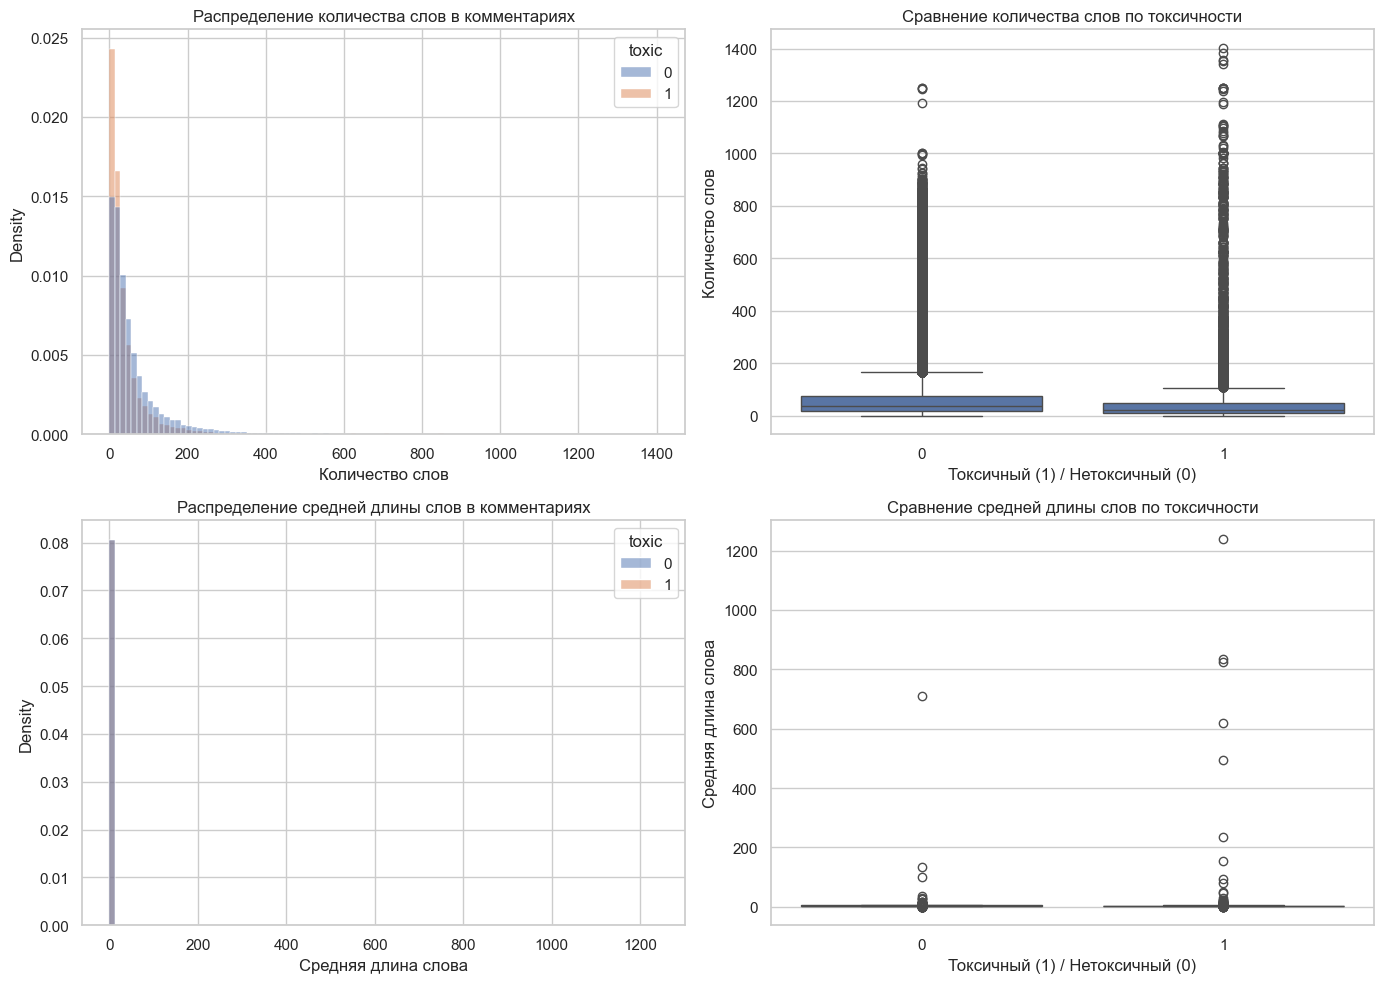

In [36]:
# 3. Визуализация: гистограммы и boxplots по признаку 'toxic'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Гистограмма: количество слов ---
sns.histplot(
    data=df_text_1,
    x='word_count',
    hue='toxic',
    stat='density',
    common_norm=False,
    kde=False,
    bins=100,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Распределение количества слов в комментариях')
axes[0, 0].set_xlabel('Количество слов')

# --- Boxplot: количество слов ---
sns.boxplot(data=df_text_1, x='toxic', y='word_count', ax=axes[0, 1])
axes[0, 1].set_title('Сравнение количества слов по токсичности')
axes[0, 1].set_xlabel('Токсичный (1) / Нетоксичный (0)')
axes[0, 1].set_ylabel('Количество слов')

# --- Гистограмма: средняя длина слов ---
sns.histplot(
    data=df_text_1,
    x='avg_word_length',
    hue='toxic',
    stat='density',
    common_norm=False,
    kde=False,
    bins=100,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Распределение средней длины слов в комментариях')
axes[1, 0].set_xlabel('Средняя длина слова')

# --- Boxplot: средняя длина слов ---
sns.boxplot(data=df_text_1, x='toxic', y='avg_word_length', ax=axes[1, 1])
axes[1, 1].set_title('Сравнение средней длины слов по токсичности')
axes[1, 1].set_xlabel('Токсичный (1) / Нетоксичный (0)')
axes[1, 1].set_ylabel('Средняя длина слова')

# Автоматическая подгонка подписей
plt.tight_layout()
plt.show()

Мы наблюдаем комментарии с аномально большим количеством слов (больше 400) и с аномально большим средним значением длины слов (больше 10). Узнаем их долю среди всех комментариев.

In [37]:
# Количество комментариев с количеством слов больше 400
l1 = len(df_text_1.query('word_count>400'))
l1

2965

In [38]:
# Количество комментариев со средним значением длины слов больше 10
l2 = len(df_text_1.query('avg_word_length>10'))
l2

79

In [39]:
print(f"Доля аномальных комментариев: {len(df_text_1.query('word_count>400 & avg_word_length<10'))/len(df_text_1)*100:.3} %")

Доля аномальных комментариев: 1.86 %


Комментариев с аномальным количеством слов и с аномальным средним количеством символов в одном слове малая доля, меньше 2%. Их можно исключить из анализа, так как они не являются статистически значимы.

In [40]:
# Исключим аномальные комментарии
df_text_1 = df_text_1.query('word_count<=400 & avg_word_length<=10')

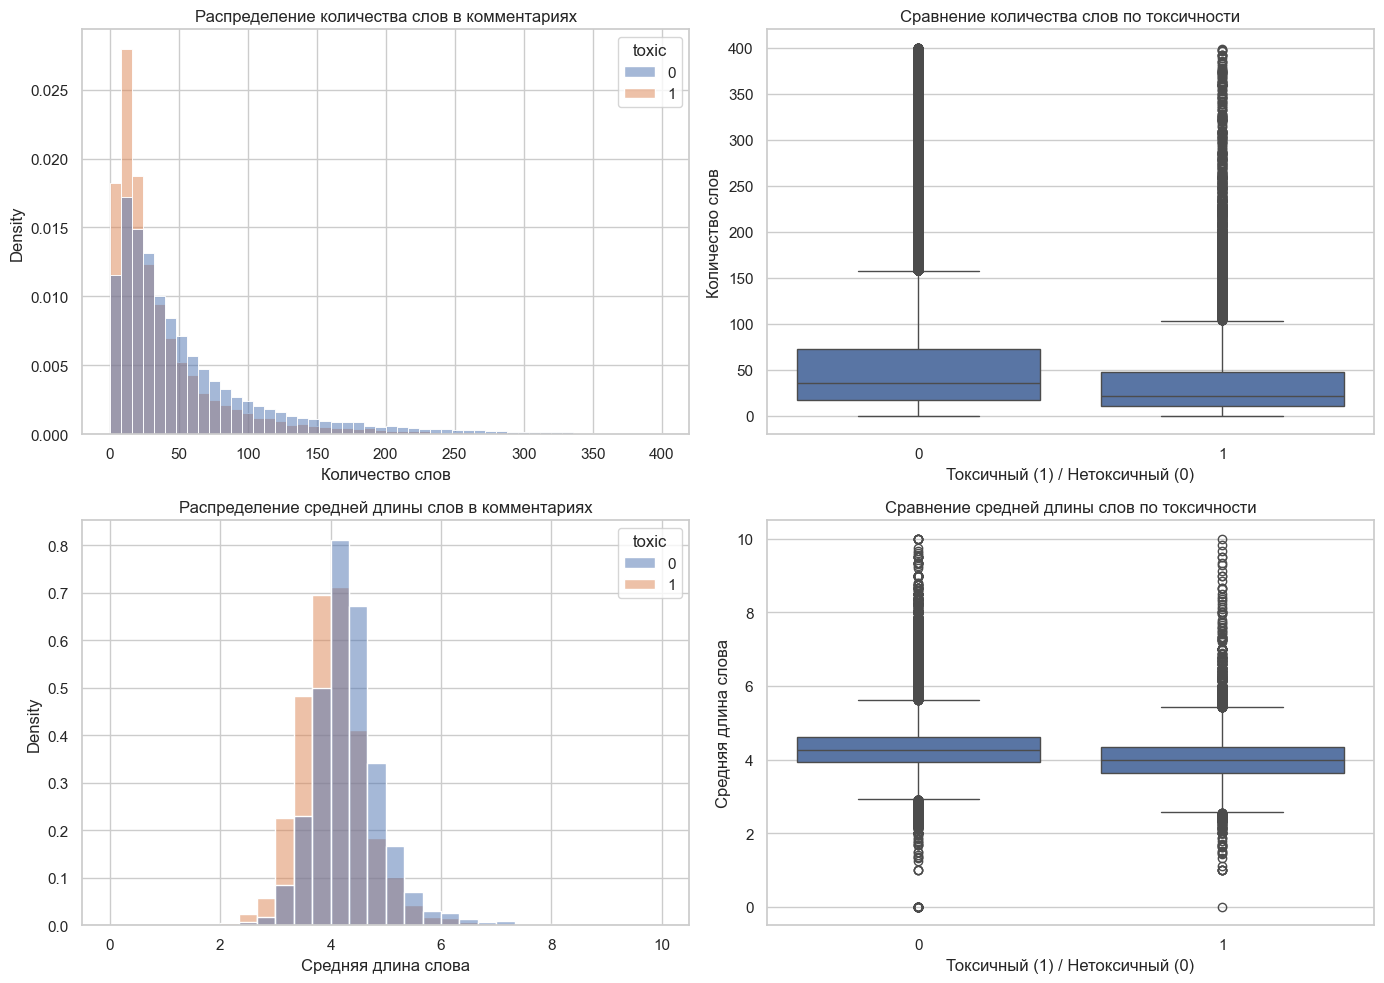

In [41]:
# 3. Визуализация комментариев с количеством слов меньше 400 и средней длинной слов меньше

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Гистограмма: количество слов ---
sns.histplot(
    data=df_text_1,
    x='word_count',
    hue='toxic',
    stat='density',
    common_norm=False,
    kde=False,
    bins=50,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Распределение количества слов в комментариях')
axes[0, 0].set_xlabel('Количество слов')

# --- Boxplot: количество слов ---
sns.boxplot(data=df_text_1, x='toxic', y='word_count', ax=axes[0, 1])
axes[0, 1].set_title('Сравнение количества слов по токсичности')
axes[0, 1].set_xlabel('Токсичный (1) / Нетоксичный (0)')
axes[0, 1].set_ylabel('Количество слов')

# --- Гистограмма: средняя длина слов ---
sns.histplot(
    data=df_text_1,
    x='avg_word_length',
    hue='toxic',
    stat='density',
    common_norm=False,
    kde=False,
    bins=30,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Распределение средней длины слов в комментариях')
axes[1, 0].set_xlabel('Средняя длина слова')

# --- Boxplot: средняя длина слов ---
sns.boxplot(data=df_text_1, x='toxic', y='avg_word_length', ax=axes[1, 1])
axes[1, 1].set_title('Сравнение средней длины слов по токсичности')
axes[1, 1].set_xlabel('Токсичный (1) / Нетоксичный (0)')
axes[1, 1].set_ylabel('Средняя длина слова')

# Автоматическая подгонка подписей
plt.tight_layout()
plt.show()

Мы наблюдаем, что распределения комментариев по количеству слов и среднему значению длины слова различаются в зависимости от целевого признака. Созданные признаки могут быть полезны для предсказательной способности модели. Поэтому оставим их в нашем датасете для обучения.

In [42]:
# Создаем датасет для обучения
df_train = df_text_1[['text_lemmatized', 'word_count', 'avg_word_length', 'toxic']]

Используем облако слов, чтобы получить общее представление о тематике и о наиболее часто встречаемых словах в токсичных и нетоксичных твитах.

In [26]:
%%time
# Разделяем тексты по классам
toxic_texts = ' '.join(df_train[df_train['toxic'] == 1]['text_lemmatized'].dropna().astype(str))
nontoxic_texts = ' '.join(df_train[df_train['toxic'] == 0]['text_lemmatized'].dropna().astype(str))

# Создаём облака слов
wordcloud_toxic = WordCloud(width=800, height=400, background_color='white', stopwords=None, margin=0).generate(toxic_texts)
wordcloud_nontoxic = WordCloud(width=800, height=400, background_color='white', stopwords=None, margin=0).generate(nontoxic_texts)

CPU times: total: 39.8 s
Wall time: 57 s


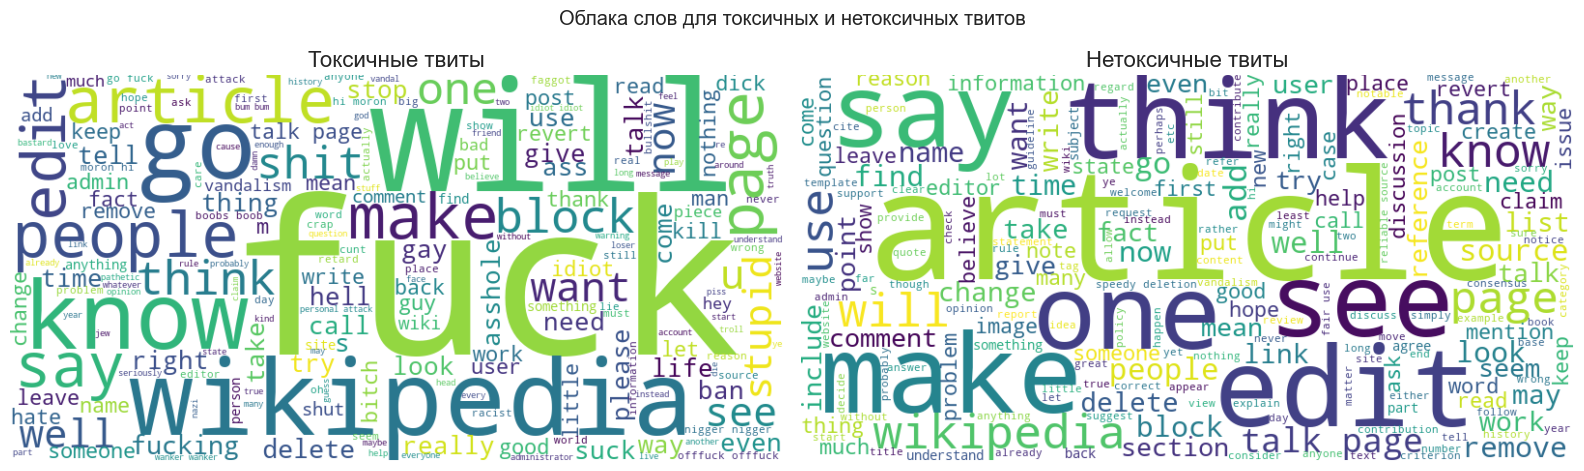

In [27]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].imshow(wordcloud_toxic, interpolation='bilinear')
axes[0].set_title('Токсичные твиты', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wordcloud_nontoxic, interpolation='bilinear')
axes[1].set_title('Нетоксичные твиты', fontsize=16)
axes[1].axis('off')

fig.suptitle('Облака слов для токсичных и нетоксичных твитов')
plt.tight_layout()
plt.show()

Невероятно, но факт!:)

**Промежуточные выводы по анализу**

1. Признаки имеют требуемый тип данных и не содержат пропуски.
2. Явные дубликаты отсутствуют.
3. Проведена очистка и лемматизация.
4. Обнаружен дисбаланс классов: превалируют позитивные комментарии (90%).
5. Комментарии с аномальным количеством слов (больше 400) и с аномальным средним количеством символов в одном слове (больше 10) удалены, так как они не являются статистически значимы.
6. Добавлены признаки количество слов и среднее значение длины слова в комментариях с целью улучшить предсказательную способность модели.

## Классификация с TF-IDF векторизацией

In [28]:
# Зададим переменную стоп-слов
english_stopwords = stopwords.words('english')

### Базовая модель: только текст (TF-IDF + LogisticRegression)

In [29]:
# Разделение данных
X = df_train['text_lemmatized']
y = df_train['toxic']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [30]:
# Pipeline: векторизация → модель
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=english_stopwords)),
    ('clf', LogisticRegression(
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Гиперпараметры для поиска
param_dist = {
    'tfidf__max_features': [10000, 50000, 100000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 3],
    'tfidf__max_df': [0.9, 0.95, 0.99],
    'clf__C': [10, 34, 100],
    'clf__penalty': ['l1', 'l2']    
}

# RandomizedSearchCV с кросс-валидацией
search_basic = RandomizedSearchCV(
    text_pipeline,
    param_dist,
    n_iter=10,
    cv=2,
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [31]:
%%time
# Обучение
search_basic.fit(X_train, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
CPU times: total: 4min 52s
Wall time: 5min 22s


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words=['a',
                                                                          'about',
                                                                          'above',
                                                                          'after',
                                                                          'again',
                                                                          'against',
                                                                          'ain',
                                                                          'all',
                                                                          'am',
                                                                          'an',
                                                                          'and',
                                                                          'any',
                                                                          'are',
                                                                          'aren',
                                                                          "aren't",
                                                                          'as',
                                                                          'at',
                                                                          'be',
                                                                          'because',
                                                                          'been',
                                                                          'before',
                                                                          'being',
                                                                          'below',
                                                                          'between',
                                                                          'both',
                                                                          'but',
                                                                          'by',
                                                                          'can',
                                                                          'couldn',
                                                                          "couldn't", ...])),
                                             ('clf',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000,
                                                                 random_state=42,
                                                                 solver='liblinear'))]),
                   n_jobs=1,
                   param_distributions={'clf__C': [10, 34, 100],
                                        'clf__penalty': ['l1', 'l2'],
                                        'tfidf__max_df': [0.9, 0.95, 0.99],
                                        'tfidf__max_features': [10000, 50000,
                                                                100000],
                                        'tfidf__min_df': [1, 2, 3],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   random_state=42, scoring='f1', verbose=1)

In [32]:
print(f"\nЛучшие параметры: {search_basic.best_params_}")
print(f"Лучший CV F1-score: {search_basic.best_score_:.4f}")


Лучшие параметры: {'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 2, 'tfidf__max_features': 50000, 'tfidf__max_df': 0.9, 'clf__penalty': 'l1', 'clf__C': 10}
Лучший CV F1-score: 0.7501


### Продвинутая модель: текст + числовые признаки (TF-IDF + LogisticRegression)

In [33]:
# Разделение данных
X = df_train[['text_lemmatized', 'word_count', 'avg_word_length']]
y = df_train['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [34]:
# ColumnTransformer: обрабатываем текст и числа отдельно
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words=english_stopwords), 'text_lemmatized'),
        ('num', StandardScaler(), ['word_count', 'avg_word_length'])
    ],
    remainder='drop'
)

# Полный pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE,
        max_iter=1000
    ))
])

# Гиперпараметры для поиска
param_dist_full = {
    'preprocessor__text__max_features': [10000, 50000, 100000],
    'preprocessor__text__ngram_range': [(1, 1), (1, 2)],
    'preprocessor__text__min_df': [1, 2, 3],
    'preprocessor__text__max_df': [0.9, 0.95, 0.99],
    'clf__C': [10, 34, 100],
    'clf__penalty': ['l1', 'l2']
}

# Поиск гиперпараметров
search_advanced = RandomizedSearchCV(
    full_pipeline,
    param_dist_full,
    n_iter=10,
    cv=2,
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [35]:
%%time
# Обучение
search_advanced.fit(X_train, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
CPU times: total: 4min 10s
Wall time: 4min 30s


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(stop_words=['a',
                                                                                                           'about',
                                                                                                           'above',
                                                                                                           'after',
                                                                                                           'again',
                                                                                                           'against',
                                                                                                           'ain',
                                                                                                           'all',
                                                                                                           'am',
                                                                                                           'an',
                                                                                                           'and',
                                                                                                           'any',
                                                                                                           'are',
                                                                                                           'aren',
                                                                                                           "aren't",
                                                                                                           'as',
                                                                                                           'at',
                                                                                                           'be',
                                                                                                           'because',
                                                                                                           'been',
                                                                                                           'before',
                                                                                                           'being',
                                                                                                           'below',
                                                                                                           'between',
                                                                                                           'both',
                                                                                                           'but',
                                                                                                           'by',
                                                                                                           'can',
                                                                                                           'couldn',
                                                                                                           "couldn't", ......
                                                                 max_iter=1000,
                                                                 random_state=42,
                                                                 solver='liblinear'))]),
                   n_jobs=1,
                   param_distributions={'clf__C': [10, 34, 100],
                     

In [36]:
print(f"\nЛучшие параметры: {search_advanced.best_params_}")
print(f"Лучший CV F1-score: {search_advanced.best_score_:.4f}")


Лучшие параметры: {'preprocessor__text__ngram_range': (1, 2), 'preprocessor__text__min_df': 2, 'preprocessor__text__max_features': 50000, 'preprocessor__text__max_df': 0.9, 'clf__penalty': 'l1', 'clf__C': 10}
Лучший CV F1-score: 0.7499


### Базовая модель: только текст (TF-IDF + XGBClassifier)

In [37]:
# Разделение данных
X = df_train['text_lemmatized']
y = df_train['toxic']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [38]:
# Pipeline: векторизация → модель
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=english_stopwords)),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        tree_method='hist',
        max_bin=128
    ))
])

# Гиперпараметры для XGBoost + TF-IDF
param_dist = {
    # Параметры TF-IDF
    'tfidf__max_features': [5000, 8000],
    'tfidf__ngram_range': [(1, 1)],
    'tfidf__min_df': [5],
    'tfidf__max_df': [0.95],
    
    # Параметры XGBoost
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [4, 6],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0],      
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__tree_method': ['hist'],
    'clf__reg_alpha': [0, 1e-6, 1e-4, 1e-2, 0.1],   # L1 регуляризация
    'clf__reg_lambda': [0, 1e-6, 1e-4, 1e-2, 1, 10]   # L2 регуляризация
}

# Поиск гиперпараметров
search_xgb_basic = RandomizedSearchCV(
    text_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [39]:
%%time
# Обучение
search_xgb_basic.fit(X_train, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
CPU times: total: 12min 31s
Wall time: 4min 44s


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words=['a',
                                                                          'about',
                                                                          'above',
                                                                          'after',
                                                                          'again',
                                                                          'against',
                                                                          'ain',
                                                                          'all',
                                                                          'am',
                                                                          'an',
                                                                          'and',
                                                                          'any',
                                                                          'are',
                                                                          'aren',
                                                                          "aren't",
                                                                          'as',
                                                                          'at',
                                                                          'be',
                                                                          'because',
                                                                          'been',
                                                                          'before',
                                                                          'being',
                                                                          'below',
                                                                          'between',
                                                                          'both',
                                                                          'but',
                                                                          'by',
                                                                          'can',
                                                                          'couldn',
                                                                          "couldn't", ...])),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booste...
                                        'clf__learning_rate': [0.05, 0.1, 0.2],
                                        'clf__max_depth': [4, 6],
                                        'clf__n_estimators': [100, 150],
                                        'clf__reg_alpha': [0, 1e-06, 0.0001,
                                                           0.01, 0.1],
                                        'clf__reg_lambda': [0, 1e-06, 0.0001,
                                                            0.01, 1, 10],
                                        'clf__subsample': [0.8, 1.0],
                                        'clf__tree_method': ['hist'],
                                        'tfidf__max_df': [0.95],
                                        'tfidf__max_features': [5000, 8000],
                                        'tfidf__min_df': [5],
                                        'tfidf__ngram_range': [(1, 1)]},
                   random_state=42, scoring='f1', verbose=1)

In [40]:
print(f"\nЛучшие параметры XGBoost: {search_xgb_basic.best_params_}")
print(f"Лучший CV F1-score (XGBoost): {search_xgb_basic.best_score_:.4f}")


Лучшие параметры XGBoost: {'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 5, 'tfidf__max_features': 5000, 'tfidf__max_df': 0.95, 'clf__tree_method': 'hist', 'clf__subsample': 1.0, 'clf__reg_lambda': 0, 'clf__reg_alpha': 0.0001, 'clf__n_estimators': 150, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}
Лучший CV F1-score (XGBoost): 0.7127


### Продвинутая модель: текст + числовые признаки (TF-IDF + XGBClassifier)

In [41]:
# Разделение данных
X = df_train[['text_lemmatized', 'word_count', 'avg_word_length']]
y = df_train['toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

In [42]:
# ColumnTransformer: текст → TF-IDF, числа → передаём как есть (StandardScaler не обязателен для XGBoost)
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(stop_words=english_stopwords), 'text_lemmatized'),
        ('num', 'passthrough', ['word_count', 'avg_word_length'])  # ← передаём числа "как есть"
    ],
    remainder='drop'
)

# Pipeline с XGBClassifier
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        tree_method='hist',
        max_bin=128
    ))
])

# Гиперпараметры для XGBoost + TF-IDF
param_dist_full = {
    # Параметры TF-IDF
    'preprocessor__text__max_features': [5000, 8000],
    'preprocessor__text__ngram_range': [(1, 1)],
    'preprocessor__text__min_df': [5],
    'preprocessor__text__max_df': [0.95],
    
    # Параметры XGBoost
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [4, 6],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0],      
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__tree_method': ['hist'],
    'clf__reg_alpha': [0, 1e-6, 1e-4, 1e-2, 0.1],   # L1 регуляризация
    'clf__reg_lambda': [0, 1e-6, 1e-4, 1e-2, 1, 10]   # L2 регуляризация
}

# Поиск гиперпараметров
search_xgb_advanced = RandomizedSearchCV(
    full_pipeline,
    param_distributions=param_dist_full,
    n_iter=10,
    cv=2,
    scoring='f1',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [43]:
%%time
# Обучение
search_xgb_advanced.fit(X_train, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits
CPU times: total: 12min 53s
Wall time: 4min 46s


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('text',
                                                                               TfidfVectorizer(stop_words=['a',
                                                                                                           'about',
                                                                                                           'above',
                                                                                                           'after',
                                                                                                           'again',
                                                                                                           'against',
                                                                                                           'ain',
                                                                                                           'all',
                                                                                                           'am',
                                                                                                           'an',
                                                                                                           'and',
                                                                                                           'any',
                                                                                                           'are',
                                                                                                           'aren',
                                                                                                           "aren't",
                                                                                                           'as',
                                                                                                           'at',
                                                                                                           'be',
                                                                                                           'because',
                                                                                                           'been',
                                                                                                           'before',
                                                                                                           'being',
                                                                                                           'below',
                                                                                                           'between',
                                                                                                           'both',
                                                                                                           'but',
                                                                                                           'by',
                                                                                                           'can',
                                                                                                           'couldn',
                                                                                                           "couldn't", ......
                                        'clf__n_estimators': [100, 150],
                                        'clf__reg_alpha': [0, 1e-06, 0.0001,
                                                           0.01, 0.1],
                                        'clf__reg_lambda': [0, 1e-06, 0.0001,
                                                            0.01, 1

In [44]:
print(f"\nЛучшие параметры XGBoost: {search_xgb_advanced.best_params_}")
print(f"Лучший CV F1-score (XGBoost): {search_xgb_advanced.best_score_:.4f}")


Лучшие параметры XGBoost: {'preprocessor__text__ngram_range': (1, 1), 'preprocessor__text__min_df': 5, 'preprocessor__text__max_features': 8000, 'preprocessor__text__max_df': 0.95, 'clf__tree_method': 'hist', 'clf__subsample': 1.0, 'clf__reg_lambda': 0.01, 'clf__reg_alpha': 0, 'clf__n_estimators': 150, 'clf__max_depth': 4, 'clf__learning_rate': 0.2, 'clf__colsample_bytree': 0.8}
Лучший CV F1-score (XGBoost): 0.7140


In [45]:
# Собираем результаты в словарь
results = {
    'Модель': [
        'XGBoost (расширенная: текст + числовые признаки)',
        'XGBoost (базовая: только текст)',
        'LogisticRegression (расширенная: текст + числовые признаки)',
        'LogisticRegression (базовая: только текст)'
    ],
    'Лучший CV F1-score': [
        search_xgb_advanced.best_score_,
        search_xgb_basic.best_score_,
        search_advanced.best_score_,
        search_basic.best_score_
    ]
}

# Создаём DataFrame
comparison_df = pd.DataFrame(results)

# Сортируем по качеству (по убыванию)
comparison_df = comparison_df.sort_values(by='Лучший CV F1-score', ascending=False).reset_index(drop=True)

# Выводим таблицу
print(comparison_df.to_string(index=False, float_format="%.4f"))

                                                     Модель  Лучший CV F1-score
                 LogisticRegression (базовая: только текст)              0.7501
LogisticRegression (расширенная: текст + числовые признаки)              0.7499
           XGBoost (расширенная: текст + числовые признаки)              0.7140
                            XGBoost (базовая: только текст)              0.7127


**Промежуточный вывод по моделям с TF-IDF векторизацией**

Числовые признаки `word_count`, `avg_word_length` не улучшили предсказательную способность моделей `LogisticRegression` и `XGBoost`, так как метрика F1-score на кросс-валидации осталась на том же уровне как и для соответтсвующих моделей без числовых признаков. Лучшей моделью на кросс-валидации среди исследуемых оказалась модель `LogisticRegression (базовая: только текст)`.

### Тестирование лучшей модели с TF-IDF векторизацией

Лучшей моделью на кросс-валидации оказалась LogisticRegression. Проведем оценку ее вариаций как с числовыми признаками, так и без них на тестовой выборке.

In [46]:
# -------------------------------------------------
# Финальная модель LogisticRegression (базовая: только текст) и оценка на тесте
# -------------------------------------------------
best_lr_basic = search_basic.best_estimator_

y_pred = best_lr_basic.predict(X_test['text_lemmatized'])
f1_test = f1_score(y_test, y_pred, zero_division=0)

print(f"\n✅ F1-score на тестовом наборе: {f1_test:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred, zero_division=0))


✅ F1-score на тестовом наборе: 0.7479

Подробный отчёт:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     35100
           1       0.70      0.80      0.75      3963

    accuracy                           0.95     39063
   macro avg       0.84      0.88      0.86     39063
weighted avg       0.95      0.95      0.95     39063



In [47]:
# -------------------------------------------------
# Финальная модель LogisticRegression (расширенная: текст + числовые признаки) и оценка на тесте
# -------------------------------------------------
best_lr_advanced = search_advanced.best_estimator_

y_pred = best_lr_advanced.predict(X_test)
f1_test = f1_score(y_test, y_pred, zero_division=0)

print(f"\n✅ F1-score на тестовом наборе: {f1_test:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test, y_pred, zero_division=0))


✅ F1-score на тестовом наборе: 0.7495

Подробный отчёт:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97     35100
           1       0.71      0.80      0.75      3963

    accuracy                           0.95     39063
   macro avg       0.84      0.88      0.86     39063
weighted avg       0.95      0.95      0.95     39063



**Промежуточные выводы по тестированию модели LogisticRegression**

Модель LogisticRegression (расширенная: текст + числовые признаки) справилась с задачей не значительно лучше, показав на тестовой выборке значение метрики f1=0.7654.

### Подбор порога классификации с целью улучшения метрики F1-score

In [48]:
# 1. Разделение данных ещё раз: train → train + val
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

# 2. Обучение модели на X_train
best_lr_advanced.fit(X_train, y_train)

# 3. Получение вероятности на валидации
y_val_proba = best_lr_advanced.predict_proba(X_val)[:, 1]  # вероятности класса 1 (токсичный)

# 4. Подбор порога по F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for th in thresholds:
    y_val_pred = (y_val_proba >= th).astype(int)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1_val = max(f1_scores)

print(f"Лучший порог: {best_threshold:.2f}, F1 на валидации: {best_f1_val:.4f}")

Лучший порог: 0.83, F1 на валидации: 0.7679


In [49]:
# Предсказание на тесте
y_test_proba = best_lr_advanced.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

f1_test = f1_score(y_test, y_test_pred, zero_division=0)
print(f"F1 на тесте с подобранным порогом: {f1_test:.4f}")

F1 на тесте с подобранным порогом: 0.7664


**Промежуточные выводы по подбору порога классификации**

Изменение порога классификации с 0.50 до 0.68 дает прирост метрике F1-score с 0.7654 до 0.7776 для модели LogisticRegression (расширенная: текст + числовые признаки)

### Оценка важности слов для классификации с точки зрения модели

In [50]:
# Получаем коэффициенты модели
coef = best_lr_advanced.named_steps['clf'].coef_[0]

In [51]:
# Слова (признаки) из TF-IDF
# Получаем обученный ColumnTransformer
preprocessor = best_lr_advanced.named_steps['preprocessor']
# Извлекаем TfidfVectorizer по имени 'text'
tfidf = preprocessor.named_transformers_['text']
# Получаем названия признаков (слова и, возможно, биграммы)
feature_names = tfidf.get_feature_names_out()

In [52]:
n_text_features = len(feature_names)  # количество слов/биграмм
n_num_features = 2  # word_count, avg_word_length

# Только веса для слов
text_weights = coef[:n_text_features]

# Веса для числовых признаков
num_weights = coef[-n_num_features:]
num_feature_names = ['word_count', 'avg_word_length']

In [53]:
word_importance = pd.DataFrame({
    'word': feature_names,
    'weight': text_weights
})

In [54]:
top_toxic = word_importance.nlargest(20, 'weight')
top_nontoxic = word_importance.nsmallest(20, 'weight')

print("Топ токсичных слов:")
print(top_toxic)

print("\nТоп нетоксичных слов:")
print(top_nontoxic)

print("\nКоэффициенты числовых признаков:")
num_weights

Топ токсичных слов:
                      word     weight
15976                 fuck  90.831442
16040              fucking  61.076933
14455               faggot  58.864697
38337                 shit  53.078040
19449                idiot  44.805086
3693               asshole  43.633669
16036               fucker  42.709645
5945              bullshit  42.699599
5090                 bitch  40.691453
41048               stupid  35.895103
7641            cocksucker  34.903773
41235                 suck  34.784967
9859                  cunt  34.645106
3656                   ass  33.960873
3495   article wikiproject  33.266686
11047             dickhead  33.217736
26462        move personal  32.424162
11040                 dick  31.381574
26406         motherfucker  31.115160
19642             imbecile  30.479637

Топ нетоксичных слов:
                 word     weight
24662         man man -51.619975
34190     really hate -46.649718
18318            heir -39.733253
46847       want well -39.2

array([ 0.32482818, -0.12170058])

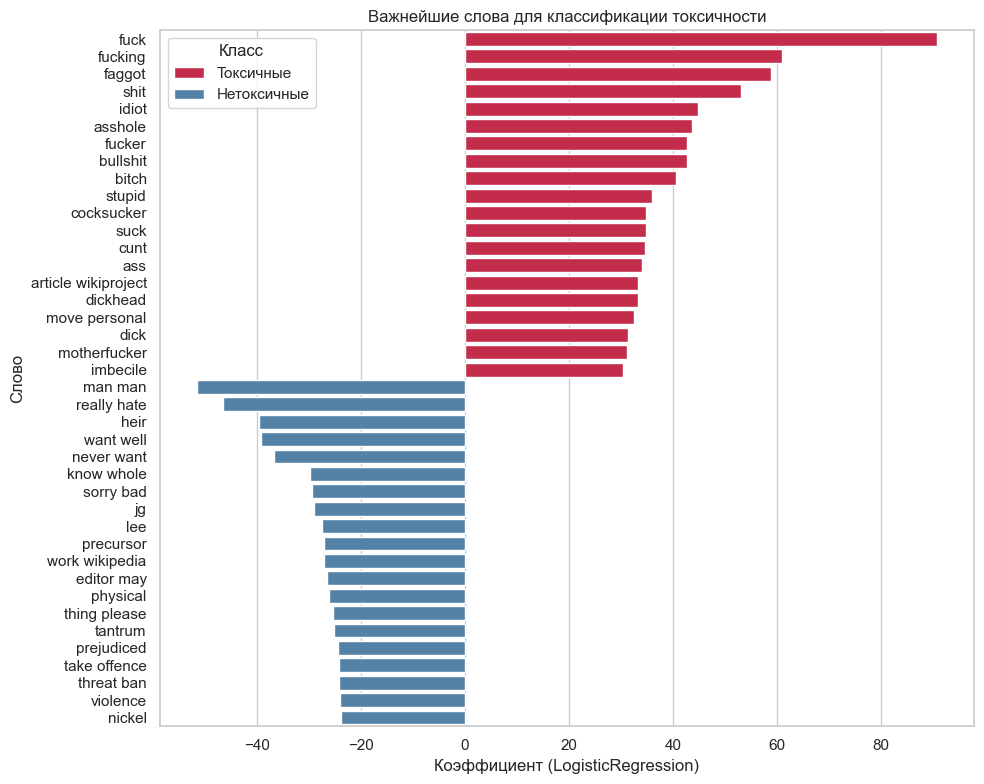

In [55]:
# Объединяем для графика
top_toxic['type'] = 'Токсичные'
top_nontoxic['type'] = 'Нетоксичные'
top_words = pd.concat([top_toxic, top_nontoxic])

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_words,
    y='word',
    x='weight',
    hue='type',
    palette={'Токсичные': 'crimson', 'Нетоксичные': 'steelblue'}
)
plt.title('Важнейшие слова для классификации токсичности')
plt.xlabel('Коэффициент (LogisticRegression)')
plt.ylabel('Слово')
plt.legend(title='Класс')
plt.tight_layout()
plt.show()

**Промежуточный вывод по важности слов**

Наблюдается ряд слов, которые являются критически важными с точки зрения определения токсичности комментария. При этом коэффициенты числовых признаков `word_count`, `avg_word_length` имеют значения коэффициентов на порядки меньше, коэффициентов самых важных слов, что согласуется с результатами сравнения метрик на одинаковых моделях с числовыми признаками и без них: где добавление чилсовых признаков не дало значимых положительных результатов.

## Классификация на эмбеддингах

### Toxic-Bert

In [56]:
# -------------------------------------------------
# 1. Конфигурация
# -------------------------------------------------
MODEL_NAME = 'unitary/toxic-bert'

texts = df_train['text_lemmatized'].astype(str).tolist()
labels = df_train['toxic'].values

# Для отладки:
len_bert = 1000
texts_bert = texts[:len_bert]
labels_bert = labels[:len_bert]

In [58]:
print(f'Доля токсичных комментариев: {sum(labels_bert)/len(labels_bert)}')

Доля токсичных комментариев: 0.112


Мы наблюдаем, что уменьшение датасета с 156249 до 1000 записей происходит с сохранением дисбаланса классов, примерно, на том же уровне 10-11%, что подтверждает правомерность данного шага с целью уменьшения времени обучения для сравнения модели `toxic-bert` с лучшей моделью среди исследуемых с применением TF-IDF векторизации.

In [59]:
# -------------------------------------------------
# 2. Загрузка BERT и токенизатора
# -------------------------------------------------
print("Загрузка BERT и токенизатора...")
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = transformers.AutoModel.from_pretrained(MODEL_NAME)

# Переводим модель в eval-режим и на CPU
bert_model.eval()
device = torch.device("cpu")
bert_model.to(device)

Загрузка BERT и токенизатора...


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

In [60]:
# -------------------------------------------------
# 3. Функция для получения эмбеддингов (с прогресс-баром)
# -------------------------------------------------
def get_bert_embeddings(texts, tokenizer, model, batch_size=16, max_length=128):
    embeddings = []
    model.eval()

    # Вычисляем общее число батчей для tqdm
    total_batches = (len(texts) + batch_size - 1) // batch_size

    with torch.no_grad():
        # Оборачиваем range в tqdm
        for i in tqdm(range(0, len(texts), batch_size),
                      total=total_batches,
                      desc="Получение BERT-эмбеддингов",
                      unit="батч"):
            batch_texts = texts[i:i + batch_size]
            encoded = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = model(**encoded)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)

            # Очистка памяти
            del encoded, outputs, cls_embeddings
            gc.collect()

    return np.vstack(embeddings)

In [61]:
%%time
# -------------------------------------------------
# 4. Получение эмбеддингов
# -------------------------------------------------
print("Получение BERT-эмбеддингов...")
X_bert = get_bert_embeddings(
    texts_bert,
    tokenizer,
    bert_model,
    batch_size=BATCH_SIZE,
    max_length=MAX_LEN
)
print(f"Форма эмбеддингов: {X_bert.shape}")

Получение BERT-эмбеддингов...


Получение BERT-эмбеддингов:   0%|          | 0/4 [00:00<?, ?батч/s]

Форма эмбеддингов: (1000, 768)
CPU times: total: 11min 15s
Wall time: 2min 58s


In [62]:
# -------------------------------------------------
# 5. Разделение на train/test
# -------------------------------------------------
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(
    X_bert, labels_bert,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels_bert
)

# Освобождаем память
del X_bert, bert_model, tokenizer
gc.collect()

17

In [63]:
%%time
# -------------------------------------------------
# 5. Классификация (LogisticRegression)
# -------------------------------------------------
print("Обучение LogisticRegression на BERT-эмбеддингах...")

# Подбор гиперпараметров
param_dist = {
    'C': loguniform(1e-3, 1e2),
}

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=lr,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search.fit(X_train_bert, y_train_bert)

print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучший CV F1-score: {random_search.best_score_:.4f}")

Обучение LogisticRegression на BERT-эмбеддингах...
Fitting 2 folds for each of 10 candidates, totalling 20 fits

Лучшие параметры: {'C': 4.5705630998014515}
Лучший CV F1-score: 0.8939
CPU times: total: 156 ms
Wall time: 7.51 s


In [64]:
# -------------------------------------------------
# Тестирвоание LogisticRegression
# -------------------------------------------------
best_bert = random_search.best_estimator_

y_pred = best_bert.predict(X_test_bert)
f1_test = f1_score(y_test_bert, y_pred, zero_division=0)

print(f"\n✅ F1-score на тестовом наборе: {f1_test:.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_test_bert, y_pred, zero_division=0))


✅ F1-score на тестовом наборе: 0.8333

Подробный отчёт:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       222
           1       0.78      0.89      0.83        28

    accuracy                           0.96       250
   macro avg       0.88      0.93      0.91       250
weighted avg       0.96      0.96      0.96       250



## Итоговый вывод

Представленные данные имеют требуемый тип данных и не содержат пропуски, явные дубликаты отсутствуют. Проведена очистка и лемматизация. Обнаружен дисбаланс классов: превалируют позитивные комментарии (90%). Комментарии с аномальным количеством слов (больше 400) и с аномальным средним количеством символов в одном слове (больше 10) удалены, так как они не являются статистически значимы. Добавление числовых признаков количество слов и среднее значение длины слова в комментариях не привело к улучшению предсказательной способности модели.

Достигнуть цели проекта — построить модель классификации комментариев на позитивные и негативны со значением метрики качества F1 не меньше 0.75 — удалось с использованием векторизации TF-IDF и модели LogisticRegression, а также модели toxic-bert. В случае векторизации TF-IDF и модели LogisticRegression удалось повысить метрику F1-score на тестовом наборе, примерно, на 1.5% за счет подбора порога классификации. При этом модели toxic-bert для получения максимального значения метрики F1-score на тестовом наборе 0.83 хватило лишь меньше 1% от всех данных (дисбаланс классов при этом сохранен), что дает значительное превосходство данной модели.